# Model Testing

Given that we have our fine tuned model (*model12-04.hdf5*), let's further test the model and see how well it generalizes to new data. We will use the following datasets:

 * **Mozilla's Common Voice Dataset (Test Set)**
 * **Speech Accent Archive Dataset**

## Mozilla's Common Voice Dataset (Test Set)

Recall that the cell below is our Melspectrogram generator from the previous notebook.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.utils import Sequence

class MelspectrogramGenerator(Sequence):
    
    def __init__(self, filenames, labels, batch_size=31):
        self.filepaths = [
            './datasets/common_voice/melspectrograms/%s' % (filename[:-4] + '.npy')
            for filename in filenames
        ]
        self.labels = labels
        self.batch_size = batch_size
        self.one_hot_encoder = {
            "under-20": 0, 
            "20-29": 1, 
            "30-39": 2, 
            "40-49": 3, 
            "50-59": 4, 
            "60+": 5
        }
    
    def __len__(self):
        return (np.ceil(len(self.filepaths) / float(self.batch_size))).astype(np.int)
    
    def __getitem__(self, index):
        start = index * self.batch_size
        stop = (index + 1) * self.batch_size
        
        batch_filepaths = self.filepaths[start: stop]
        batch_labels = self.labels[start: stop]
        
        x_batch = []
        for filepath in batch_filepaths:
            x_batch.append(np.load(filepath))
            
        x_batch = np.array(x_batch)
        y_batch = np.zeros((len(batch_labels), 6))
        
        for i, batch_label in enumerate(batch_labels):
            j = self.one_hot_encoder[batch_label]
            y_batch[i, j] = 1
        
        return x_batch, y_batch

From here we will create a data generator from the *testing.csv* file.

In [2]:
def data_generator(filepath):
    dataframe = pd.read_csv(filepath)
    
    filenames = list(dataframe.filename)
    labels = list(dataframe.age)
    generator = MelspectrogramGenerator(filenames, labels)
    
    return generator

testing_generator = data_generator("./datasets/common_voice/testing.csv")

Let's load up the model, and get both the predictions and actuals from our Common Voice test set.

In [3]:
from tensorflow.keras.models import load_model

model = load_model('models/hdf5/model12/model12-04.hdf5')

predictions = model.predict(testing_generator)
predictions = predictions.argmax(axis=1)

testing_df = pd.read_csv("./datasets/common_voice/testing.csv")
labels = ["under-20", "20-29", "30-39", "40-49", "50-59", "60+"]

actuals = testing_df.age.apply(lambda age: labels.index(age))
actuals = np.array(actuals)

2023-01-09 13:37:18.397152: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-09 13:37:18.414015: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-09 13:37:18.414553: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-09 13:37:18.415492: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

Once that is done, we will compute the accuracy score, and generate our confusion matrices:
 * Recall and Miss Rate
 * Precision and False Discovery

In [4]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(actuals, predictions)
accuracy = round(accuracy, 4)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.9154


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics import confusion_matrix

def recall_confusion_plot(actuals, predictions):
    confusion = confusion_matrix(actuals, predictions)
    confusion = confusion.astype("float") / confusion.sum(axis=1).reshape(-1,1)
    
    df_cm = pd.DataFrame(confusion, index=labels, columns=labels)
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'
    
    plt.figure(figsize=(20, 14))
    plt.title("Recall and Miss Rate")
    sns.set(font_scale=1.4)
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16})
    plt.show()
    
def precision_confusion_plot(actuals, predictions):
    confusion = confusion_matrix(actuals, predictions)
    confusion = confusion.astype("float") / confusion.sum(axis=0)
    
    df_cm = pd.DataFrame(confusion, index=labels, columns=labels)
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'
    
    plt.figure(figsize=(20, 14))
    plt.title("Precision and False Discovery")
    sns.set(font_scale=1.4)
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16})
    plt.show()

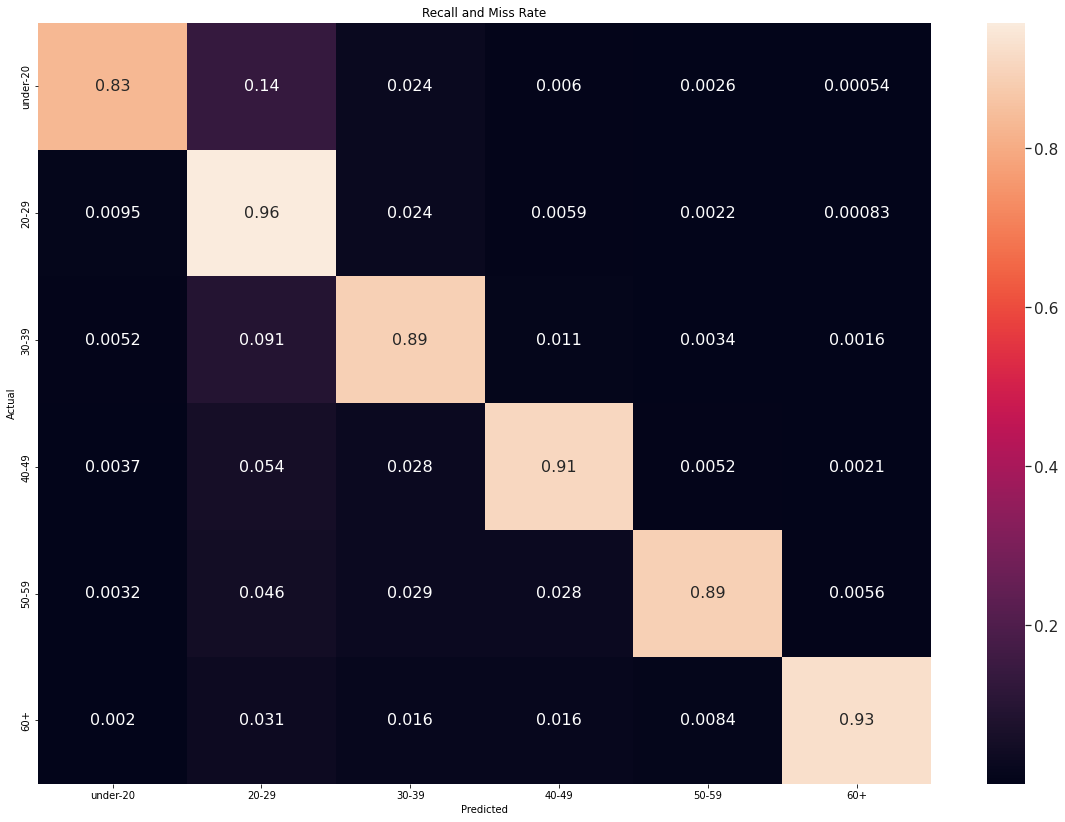

In [6]:
#Rows add up to 1
recall_confusion_plot(actuals, predictions)

The above plot is the ***Recall and Miss Rate Confusion Matrix***. 
 * All the rows of the above matrix add up to one. 
 * The diagonal values correspond to recall scores, while the off diagonal scores correspond to the miss rate scores. 
 * The value at the *i*th row, and *j*th column is the probability that the model predicts the audio sample belongs to the *j*th column given that the audio sample actually belongs to the *i*th row.

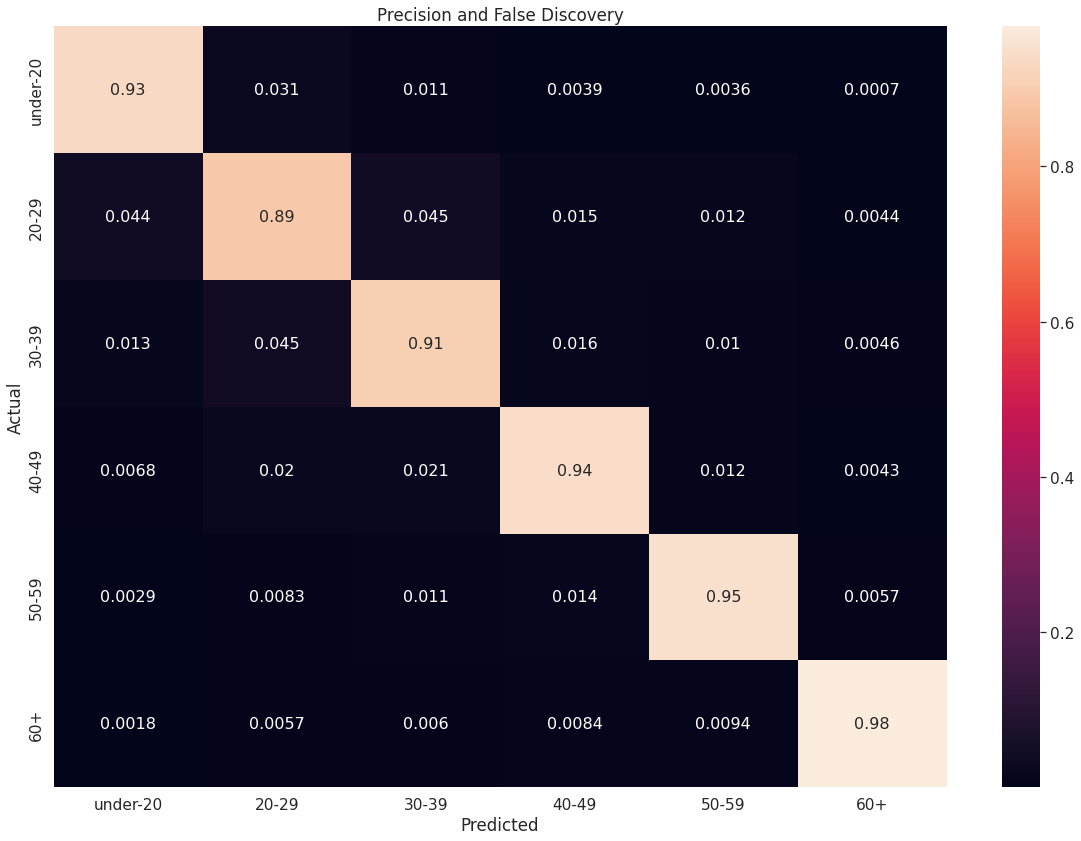

In [7]:
#Columns add up to 1
precision_confusion_plot(actuals, predictions)

The above plot is the ***Precision and False Discovery Confusion Matrix***. 
 * All the columns of the above matrix add up to one. 
 * The diagonal values correspond to precision scores, while the off diagonal scores correspond to the false discovery scores. 
 * The value at the *i*th row, and *j*th column is the probability that the audio sample actually belongs to the *i*th row given that the model predicts the audio sample belongs to the *j*th column.

## Speech Accent Archive Dataset

Next, we will test the model against the speech accent archive dataset.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.utils import Sequence

class MelspectrogramGenerator(Sequence):
    
    def __init__(self, filenames, labels, batch_size=31):
        self.filepaths = [
            './datasets/speech_accent_archive/melspectrograms/%s' % (filename[:-4] + '.npy')
            for filename in filenames
        ]
        self.labels = labels
        self.batch_size = batch_size
        self.one_hot_encoder = {
            "under-20": 0, 
            "20-29": 1, 
            "30-39": 2, 
            "40-49": 3, 
            "50-59": 4, 
            "60+": 5
        }
    
    def __len__(self):
        return (np.ceil(len(self.filepaths) / float(self.batch_size))).astype(np.int)
    
    def __getitem__(self, index):
        start = index * self.batch_size
        stop = (index + 1) * self.batch_size
        
        batch_filepaths = self.filepaths[start: stop]
        batch_labels = self.labels[start: stop]
        
        x_batch = []
        for filepath in batch_filepaths:
            x_batch.append(np.load(filepath))
            
        x_batch = np.array(x_batch)
        y_batch = np.zeros((len(batch_labels), 6))
        
        for i, batch_label in enumerate(batch_labels):
            j = self.one_hot_encoder[batch_label]
            y_batch[i, j] = 1
        
        return x_batch, y_batch

Same as before, we will create a MelspectrogramGenerator, and use it to create our test set.

In [2]:
def data_generator(filepath):
    dataframe = pd.read_csv(filepath)
    
    filenames = list(dataframe.filename)
    labels = list(dataframe.age)
    generator = MelspectrogramGenerator(filenames, labels)
    
    return generator

testing_generator = data_generator("./datasets/speech_accent_archive/metadata(1).csv")

In [3]:
from tensorflow.keras.models import load_model

model = load_model('models/hdf5/model12/model12-04.hdf5')

predictions = model.predict(testing_generator)
predictions = predictions.argmax(axis=1)

testing_df = pd.read_csv("./datasets/speech_accent_archive/metadata(1).csv")
labels = ["under-20", "20-29", "30-39", "40-49", "50-59", "60+"]

actuals = testing_df.age.apply(lambda age: labels.index(age))
actuals = np.array(actuals)

2023-01-09 13:57:27.723274: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-09 13:57:27.727888: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-09 13:57:27.728417: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-09 13:57:27.729283: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [4]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(actuals, predictions)
accuracy = round(accuracy, 4)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.333


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics import confusion_matrix

def recall_confusion_plot(actuals, predictions):
    confusion = confusion_matrix(actuals, predictions)
    confusion = confusion.astype("float") / confusion.sum(axis=1).reshape(-1,1)
    
    df_cm = pd.DataFrame(confusion, index=labels, columns=labels)
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'
    
    plt.figure(figsize=(20, 14))
    plt.title("Recall and Miss Rate")
    sns.set(font_scale=1.4)
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16})
    plt.show()
    
def precision_confusion_plot(actuals, predictions):
    confusion = confusion_matrix(actuals, predictions)
    confusion = confusion.astype("float") / confusion.sum(axis=0)
    
    df_cm = pd.DataFrame(confusion, index=labels, columns=labels)
    df_cm.index.name = 'Actual'
    df_cm.columns.name = 'Predicted'
    
    plt.figure(figsize=(20, 14))
    plt.title("Precision and False Discovery")
    sns.set(font_scale=1.4)
    sns.heatmap(df_cm, annot=True, annot_kws={"size": 16})
    plt.show()

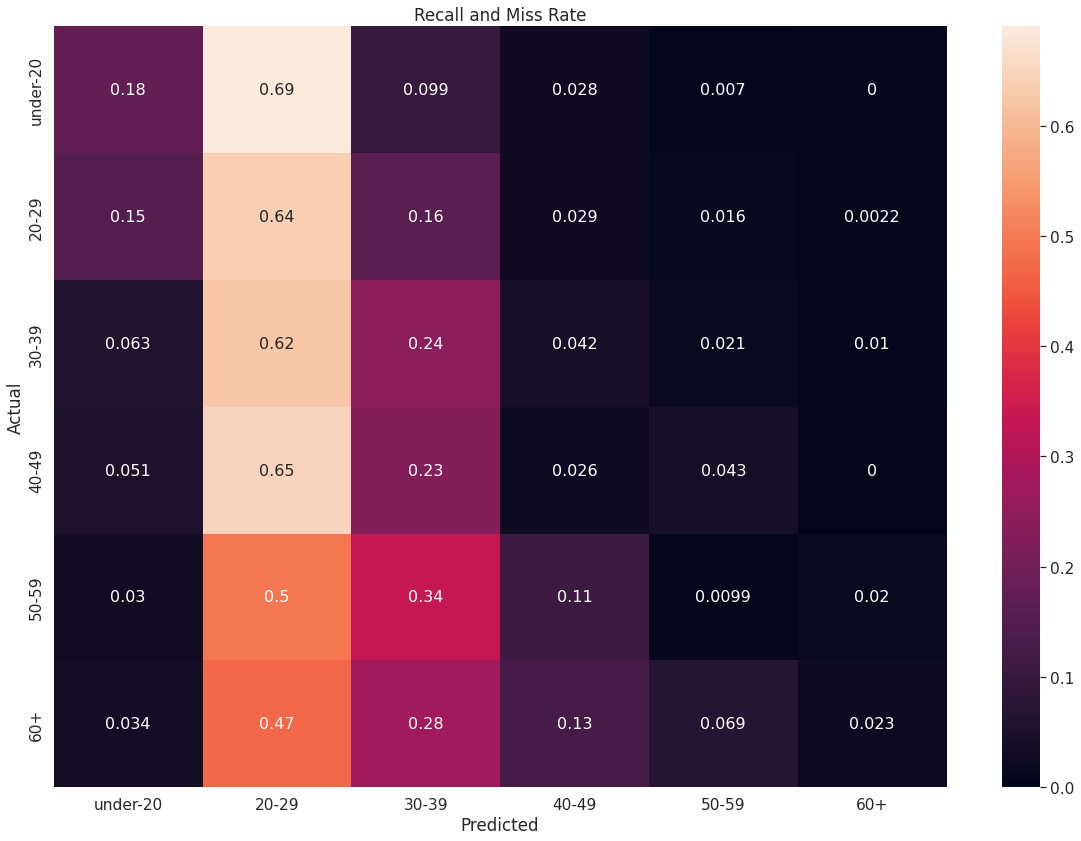

In [7]:
#Rows add up to 1
recall_confusion_plot(actuals, predictions)

The above plot is the ***Recall and Miss Rate Confusion Matrix***. 
 * All the rows of the above matrix add up to one. 
 * The diagonal values correspond to recall scores, while the off diagonal scores correspond to the miss rate scores. 
 * The value at the *i*th row, and *j*th column is the probability that the model predicts the audio sample belongs to the *j*th column given that the audio sample actually belongs to the *i*th row.

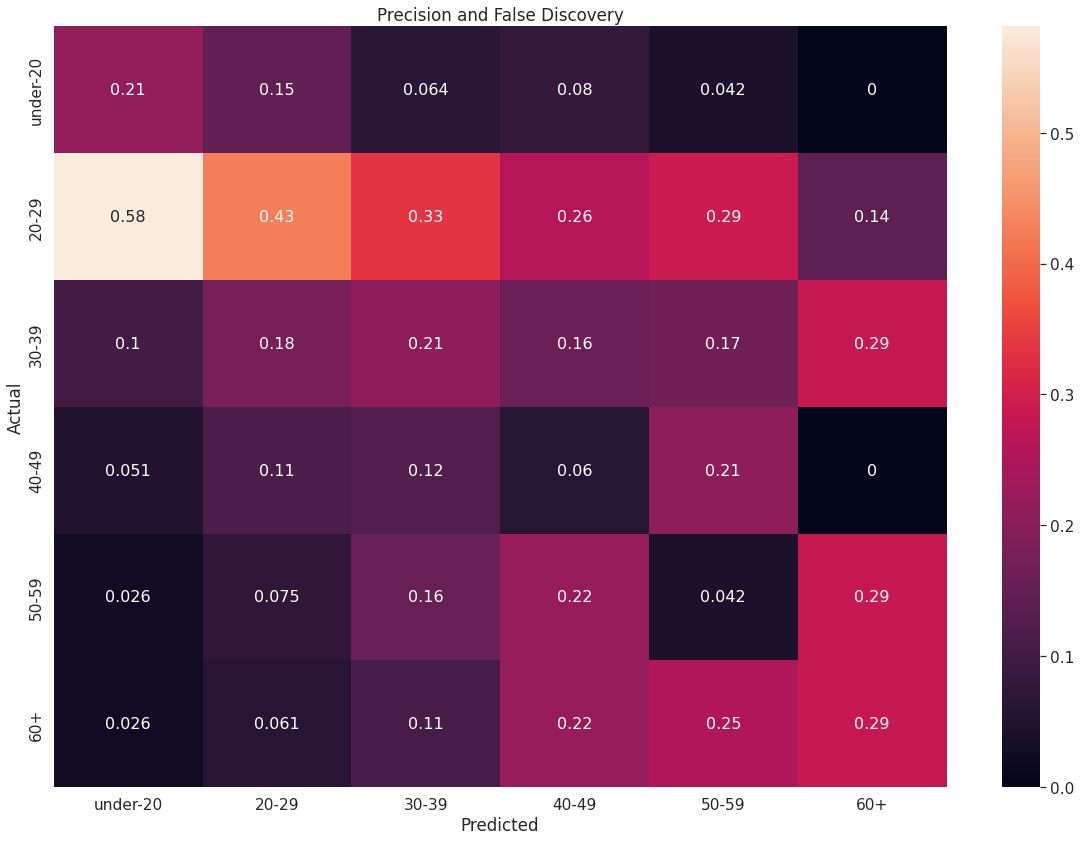

In [8]:
#Columns add up to 1
precision_confusion_plot(actuals, predictions)

The above plot is the ***Precision and False Discovery Confusion Matrix***. 
 * All the columns of the above matrix add up to one. 
 * The diagonal values correspond to precision scores, while the off diagonal scores correspond to the false discovery scores. 
 * The value at the *i*th row, and *j*th column is the probability that the audio sample actually belongs to the *i*th row given that the model predicts the audio sample belongs to the *j*th column.